Hypergraph codes are H1 = H2

and Hx = (H1 dot I2T, I1 dot H2T)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pymatching

# Match the colour scheme used in GKP_toric_animation.ipynb
X_COLOUR = 'darkorchid'
Z_COLOUR = 'crimson'
QUBIT_COLOUR = '#5F9EA0'  # Cadet Blue
COPY_COLOUR = 'lightgray'
COPY_EDGE_COLOUR = 'dimgray'

[[1 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 1]]
[[1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 1]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


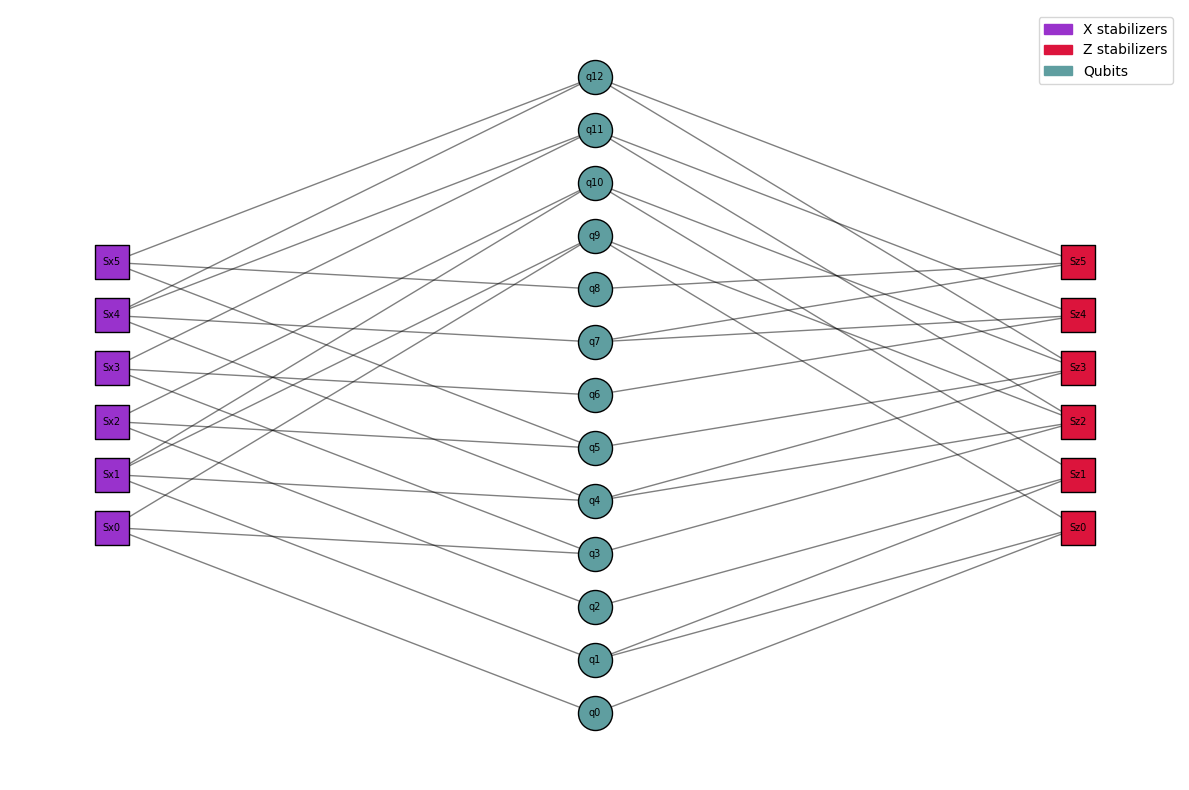

In [2]:
def repetition_code(n):
    H = np.zeros((n-1, n), dtype=int)
    for i in range(n-1):
        H[i, i]   = 1
        H[i, i+1] = 1
    return H

H1 = repetition_code(3)
H2 = repetition_code(3)
H2T = H2.T
r1, n1 = H1.shape
r2, n2 = H2.shape
I2T = np.eye(n2, dtype=int) #identity matrix in the shape of the rows of H1 or H2
I1 = np.eye(r1, dtype=int) #identity matrix in the shape of the columns of H1 or H2

def hypergraphHxHz(H1, H2T, I1, I2T):
    """
    Args:
        H1 (array?): 3 bit code thing
        H2 (_type_): same as above
        I1 (_type_): identity matrix 
        I2T (_type_): identity matrix

    Returns: 
        Hx, Hz for hypergraph codes
    """
    Hxr = np.kron(H1, I2T)
    Hxl= np.kron(I1, H2T)
    Hx = np.hstack([Hxr, Hxl])

    Hzr = np.kron(I2T, H1)
    Hzl = np.kron(H2T, I1)
    Hz = np.hstack([Hzr, Hzl])
    return Hx, Hz

Hx, Hz = hypergraphHxHz(H1, H2T, I1, I2T) #this gives a list of which stabilisers (rows) touch which qubits (columns)
#print(I2T)
print(Hx)
print(Hz)

def verify_HxHz(Hx, Hz):
    """
    Args:
        Hx (_type_): a matrix to show where the X type stabilisers connect
        Hz (_type_): a matrix to show where the Z type stabilisers connect

    Return:
        Hx dot Hz^T
    """
    return (Hx @ Hz.T) % 2 # do np.dot but in mod 2 GF2

print(verify_HxHz(Hx, Hz))

def tanner_image(Hx, Hz):
    """
    Args:
        Hx (_type_): a matrix to show where the X type stabilisers connect
        Hz (_type_): a matrix to show where the Z type stabilisers connect

    Returns:
        image of surface code
    """
    G = nx.Graph()
    n_qubits = Hx.shape[1]
    
    qubit_nodes = [f"q{i}"  for i in range(n_qubits)]
    Sx_nodes = [f"Sx{i}" for i in range(Hx.shape[0])]
    Sz_nodes = [f"Sz{i}" for i in range(Hz.shape[0])]

    # makes all the qubits and spabilisers appear
    G.add_nodes_from(qubit_nodes, bipartite = 0)
    G.add_nodes_from(Sx_nodes, bipartate = 1)
    G.add_nodes_from(Sz_nodes, bipartate = 2)

    #connections between them
    for i, row in enumerate(Hx):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sx{i}", f"q{j}")
    for i, row in enumerate(Hz):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sz{i}", f"q{j}")
        
    pos= {}
    for i, n in enumerate(Sx_nodes):
        pos[n] = (-2, i -len(Sx_nodes)/2)
    for i, n in enumerate(qubit_nodes):
        pos[n] = (0, i -len(qubit_nodes)/2)
    for i, n in enumerate(Sz_nodes):
        pos[n] = (2, i -len(Sz_nodes)/2)

    fig, ax = plt.subplots(figsize = (12,8))
    nx.draw_networkx_nodes(G, pos, nodelist= qubit_nodes, node_shape="o", node_color=QUBIT_COLOUR, node_size=600, edgecolors='black', ax=ax) 
    nx.draw_networkx_nodes(G, pos, nodelist= Sx_nodes, node_shape="s", node_color=X_COLOUR, node_size=600, edgecolors='black', ax=ax) 
    nx.draw_networkx_nodes(G, pos, nodelist= Sz_nodes, node_shape="s", node_color=Z_COLOUR, node_size=600, edgecolors='black', ax=ax) 
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5) 

    legend = [mpatches.Patch(color=X_COLOUR,    label="X stabilizers"),
              mpatches.Patch(color=Z_COLOUR,   label="Z stabilizers"),
              mpatches.Patch(color=QUBIT_COLOUR, label="Qubits")]
    ax.legend(handles=legend)
    #ax.set_title("Hypergraph Product Code — Tanner Graph")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

tanner_image(Hx, Hz)

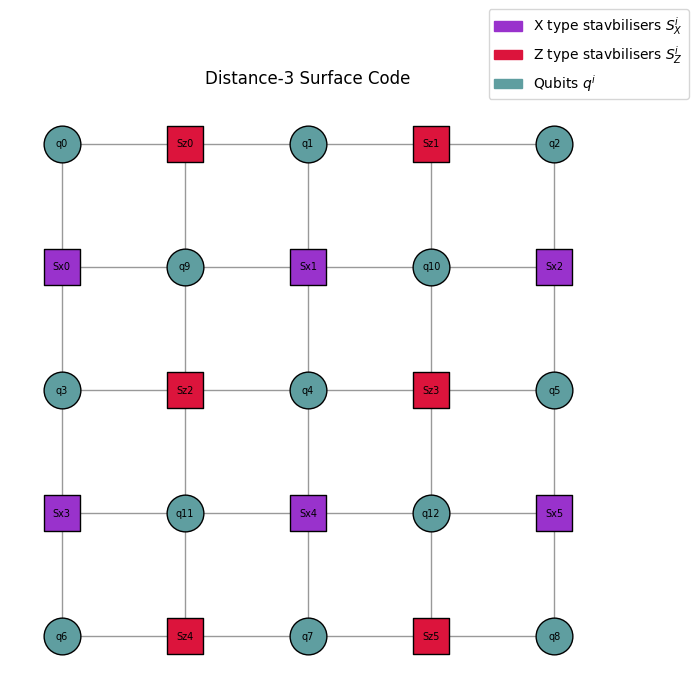

In [3]:
#make the surafec code
#need a grid
#have the correct nodes between things to yay!

def surface_code_image(Hx, Hz, show_node_labels=True):
    """_summary_

    Args:
        Hx (_type_): tells you where Sx connect
        HZ (_type_): matrix of Sz connections
    
    Returns: 
        Surface code diagram
    """
    
    G = nx.Graph()
    d = 3 # bc using H=H1+H2 w distance 3
    
    #same labels as in tanner graph function - should i make it a seperate function to call in both?
    n_qubits = Hx.shape[1]
    qubit_nodes = [f"q{i}"  for i in range(n_qubits)]
    Sx_nodes = [f"Sx{i}" for i in range(Hx.shape[0])]
    Sz_nodes = [f"Sz{i}" for i in range(Hz.shape[0])]
    
    G.add_nodes_from(qubit_nodes)
    G.add_nodes_from(Sx_nodes)
    G.add_nodes_from(Sz_nodes)

    for i, row in enumerate(Hx):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sx{i}", f"q{j}")
    for i, row in enumerate(Hz):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sz{i}", f"q{j}")
    
    pos = {
        # Row 4 (top)
        "q0":  (0, 4), "Sz0": (1, 4), "q1":  (2, 4), "Sz1": (3, 4), "q2":  (4, 4),
        # Row 3
        "Sx0": (0, 3), "q9":  (1, 3), "Sx1": (2, 3), "q10": (3, 3), "Sx2": (4, 3),
        # Row 2
        "q3":  (0, 2), "Sz2": (1, 2), "q4":  (2, 2), "Sz3": (3, 2), "q5":  (4, 2),
        # Row 1
        "Sx3": (0, 1), "q11": (1, 1), "Sx4": (2, 1), "q12": (3, 1), "Sx5": (4, 1),
        # Row 0 (bottom)
        "q6":  (0, 0), "Sz4": (1, 0), "q7":  (2, 0), "Sz5": (3, 0), "q8":  (4, 0),
    }
    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_nodes(G, pos, nodelist=qubit_nodes, node_shape="o",
                           node_color=QUBIT_COLOUR, node_size=700, edgecolors='black', ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=Sx_nodes, node_shape="s",
                           node_color=X_COLOUR,    node_size=700, edgecolors='black', ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=Sz_nodes, node_shape="s",
                           node_color=Z_COLOUR,   node_size=700, edgecolors='black', ax=ax)
    if show_node_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)

    legend = [mpatches.Patch(color=X_COLOUR,    label="X type stavbilisers $S_X^i$"),
              mpatches.Patch(color=Z_COLOUR,   label="Z type stavbilisers $S_Z^i$"),
              mpatches.Patch(color=QUBIT_COLOUR, label="Qubits $q^i$")]
    ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.15, 1.15))
    ax.set_title(f"Distance-{d} Surface Code")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

surface_code_image(Hx, Hz)

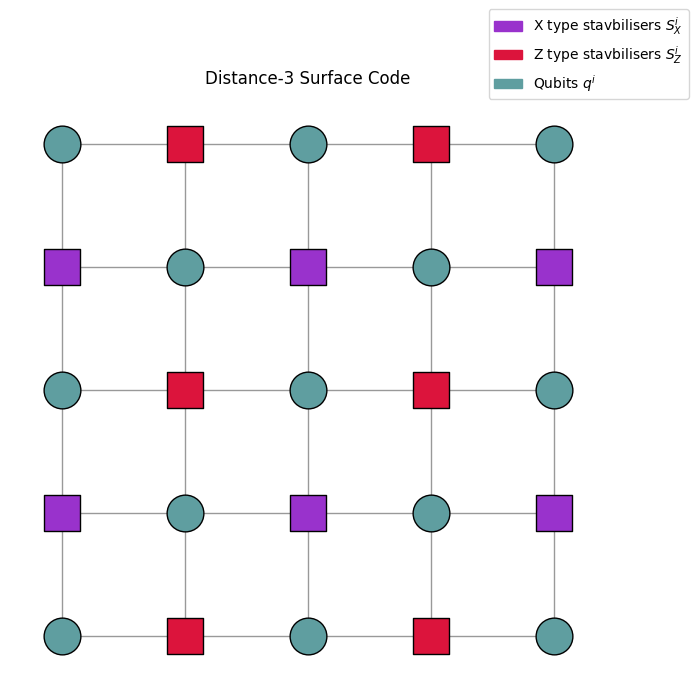

In [4]:
## Surface-code layer without node labels
# Uses the same layout and colours as above, matching the toric diagram.
surface_code_image(Hx, Hz, show_node_labels=False)


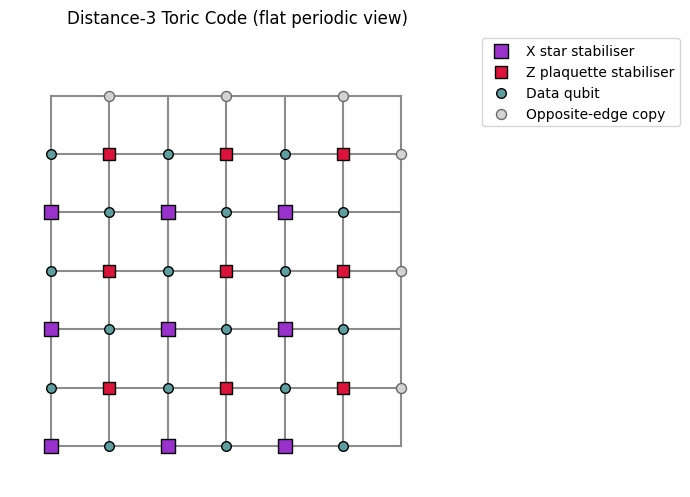

In [5]:
## Flat toric-code layer in the same visual style

def toric_code_image(d=3):
    """Draw a flat d x d toric-code fundamental domain.

    Qubits on the right and bottom boundaries are grey duplicates of the
    corresponding left and top edge qubits, making the periodic identification
    visible without drawing the torus in 3D.
    """
    fig, ax = plt.subplots(figsize=(7, 7))

    # Square fundamental domain and its lattice edges.
    for i in range(d + 1):
        ax.plot([0, d], [i, i], color='0.55', lw=1.5, zorder=1)
        ax.plot([i, i], [0, d], color='0.55', lw=1.5, zorder=1)

    # X stars live at vertices; Z plaquettes live at face centres.
    stars = [(x, y) for y in range(d) for x in range(d)]
    plaquettes = [(x + 0.5, y + 0.5) for y in range(d) for x in range(d)]

    # One representative for each toric edge qubit.
    horizontal = [(x + 0.5, y) for y in range(d) for x in range(d)]
    vertical = [(x, y + 0.5) for y in range(d) for x in range(d)]
    qubits = horizontal + vertical

    # Periodic copies: right = left and bottom = top.
    copied_right = [(d, y + 0.5) for y in range(d)]
    copied_top = [(x + 0.5, d) for x in range(d)]
    copies = copied_right + copied_top

    # Explicit Z-check incidence: each plaquette connects to the four edge
    # qubits on its boundary. At the top and right edges these terminate on
    # the grey periodic copies shown in the fundamental-domain view.
    for y in range(d):
        for x in range(d):
            plaquette = (x + 0.5, y + 0.5)
            incident_qubits = [
                (x + 0.5, y), (x + 0.5, y + 1),
                (x, y + 0.5), (x + 1, y + 0.5),
            ]
            for qubit in incident_qubits:
                ax.plot([plaquette[0], qubit[0]],
                        [plaquette[1], qubit[1]],
                        color='0.55', lw=1.5, zorder=2)

    sx, sy = zip(*stars)
    px, py = zip(*plaquettes)
    qx, qy = zip(*qubits)
    gx, gy = zip(*copies)

    ax.scatter(sx, sy, c=X_COLOUR, marker='s', s=95,
               edgecolors='black', zorder=4, label='X star stabiliser')
    ax.scatter(px, py, c=Z_COLOUR, marker='s', s=80,
               edgecolors='black', zorder=3, label='Z plaquette stabiliser')
    ax.scatter(qx, qy, c=QUBIT_COLOUR, marker='o', s=48,
               edgecolors='black', zorder=5, label='Data qubit')
    ax.scatter(gx, gy, c=COPY_COLOUR, marker='o', s=52,
               edgecolors=COPY_EDGE_COLOUR, zorder=5,
               label='Opposite-edge copy')

    ax.set_title(f'Distance-{d} Toric Code (flat periodic view)')
    ax.set_aspect('equal')
    ax.set_xlim(-0.35, d + 0.55)
    ax.set_ylim(-0.35, d + 0.55)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

toric_code_image(d=3)


## Toric-code rounds with intermediate measurements
Integer-height layers are complete planar views of the periodic toric code. Green nodes form a measurement round halfway between each pair of consecutive toric rounds and lie on the stabilizer world-lines. Thus, $T$ toric rounds contain $T-1$ intermediate measurement rounds.

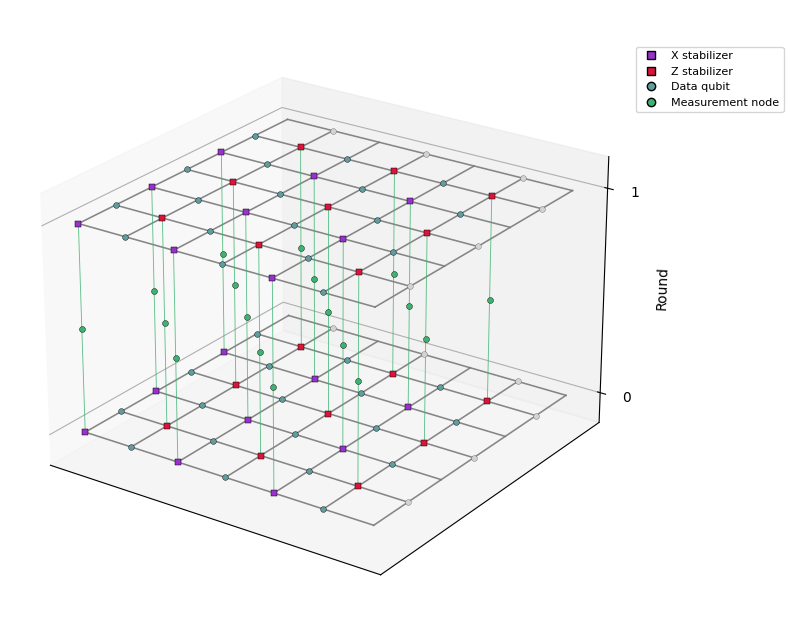

In [6]:
import importlib
import plot_toric_measurement_rounds

importlib.reload(plot_toric_measurement_rounds)
T = 2  # Number of complete toric-code rounds
plot_toric_measurement_rounds.plot_toric_measurement_rounds(
    d=3, T=T, save_path='toric_code_with_measurement_rounds.png'
)
plt.show()

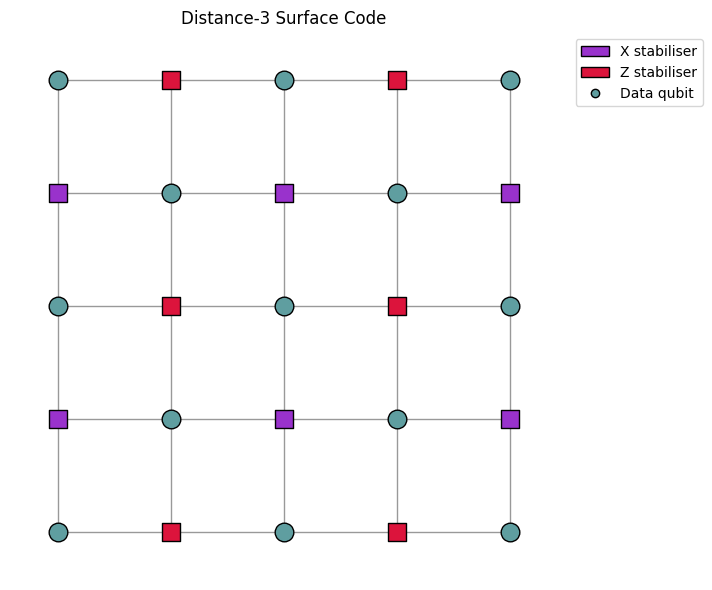

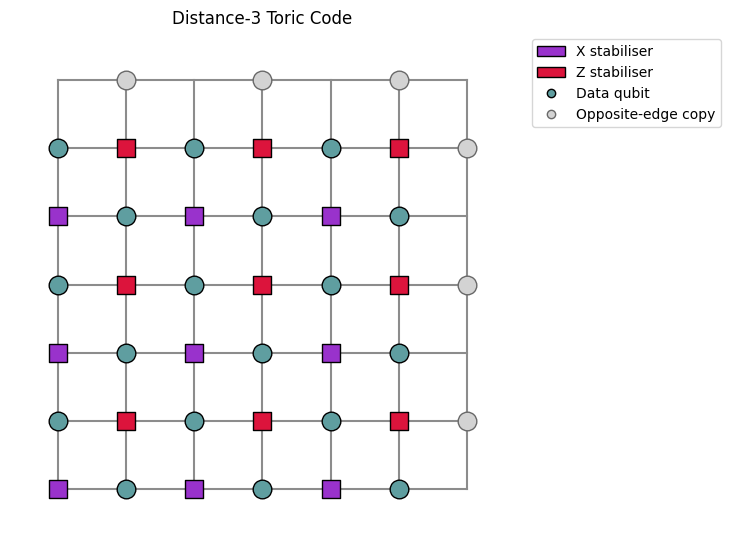

In [7]:
## Surface and toric codes as two separate plots
def compare_surface_and_toric(Hx, Hz, d=3):
    fig_surface, ax_surface = plt.subplots(figsize=(7, 6))
    fig_toric, ax_toric = plt.subplots(figsize=(7, 6))
    node_size = 180  # Identical marker area in both panels.

    # Surface-code panel (same layout as surface_code_image, without node labels).
    G = nx.Graph()
    qubits = [f'q{i}' for i in range(Hx.shape[1])]
    x_stabilisers = [f'Sx{i}' for i in range(Hx.shape[0])]
    z_stabilisers = [f'Sz{i}' for i in range(Hz.shape[0])]
    G.add_nodes_from(qubits + x_stabilisers + z_stabilisers)
    for i, row in enumerate(Hx):
        for j, value in enumerate(row):
            if value:
                G.add_edge(f'Sx{i}', f'q{j}')
    for i, row in enumerate(Hz):
        for j, value in enumerate(row):
            if value:
                G.add_edge(f'Sz{i}', f'q{j}')

    surface_pos = {
        'q0': (0, 4), 'Sz0': (1, 4), 'q1': (2, 4), 'Sz1': (3, 4), 'q2': (4, 4),
        'Sx0': (0, 3), 'q9': (1, 3), 'Sx1': (2, 3), 'q10': (3, 3), 'Sx2': (4, 3),
        'q3': (0, 2), 'Sz2': (1, 2), 'q4': (2, 2), 'Sz3': (3, 2), 'q5': (4, 2),
        'Sx3': (0, 1), 'q11': (1, 1), 'Sx4': (2, 1), 'q12': (3, 1), 'Sx5': (4, 1),
        'q6': (0, 0), 'Sz4': (1, 0), 'q7': (2, 0), 'Sz5': (3, 0), 'q8': (4, 0),
    }
    nx.draw_networkx_edges(G, surface_pos, ax=ax_surface, alpha=0.4)
    nx.draw_networkx_nodes(G, surface_pos, nodelist=qubits, node_shape='o',
                           node_color=QUBIT_COLOUR, node_size=node_size, edgecolors='black', ax=ax_surface)
    nx.draw_networkx_nodes(G, surface_pos, nodelist=x_stabilisers, node_shape='s',
                           node_color=X_COLOUR, node_size=node_size, edgecolors='black', ax=ax_surface)
    nx.draw_networkx_nodes(G, surface_pos, nodelist=z_stabilisers, node_shape='s',
                           node_color=Z_COLOUR, node_size=node_size, edgecolors='black', ax=ax_surface)
    ax_surface.set_title(f'Distance-{d} Surface Code')
    ax_surface.set_aspect('equal')
    ax_surface.axis('off')

    # Flat toric-code panel with grey periodic copies.
    for i in range(d + 1):
        ax_toric.plot([0, d], [i, i], color='0.55', lw=1.5, zorder=1)
        ax_toric.plot([i, i], [0, d], color='0.55', lw=1.5, zorder=1)
    stars = [(x, y) for y in range(d) for x in range(d)]
    plaquettes = [(x + 0.5, y + 0.5) for y in range(d) for x in range(d)]
    data_qubits = ([(x + 0.5, y) for y in range(d) for x in range(d)] +
                   [(x, y + 0.5) for y in range(d) for x in range(d)])
    copies = ([(d, y + 0.5) for y in range(d)] +
              [(x + 0.5, d) for x in range(d)])
    # Connect every Z plaquette to its four incident edge qubits.
    for y in range(d):
        for x in range(d):
            plaquette = (x + 0.5, y + 0.5)
            incident_qubits = [
                (x + 0.5, y), (x + 0.5, y + 1),
                (x, y + 0.5), (x + 1, y + 0.5),
            ]
            for qubit in incident_qubits:
                ax_toric.plot([plaquette[0], qubit[0]],
                              [plaquette[1], qubit[1]],
                              color='0.55', lw=1.5,
                              zorder=2)
    sx, sy = zip(*stars)
    px, py = zip(*plaquettes)
    qx, qy = zip(*data_qubits)
    gx, gy = zip(*copies)
    ax_toric.scatter(sx, sy, c=X_COLOUR, marker='s', s=node_size, edgecolors='black', zorder=4)
    ax_toric.scatter(px, py, c=Z_COLOUR, marker='s', s=node_size, edgecolors='black', zorder=3)
    ax_toric.scatter(qx, qy, c=QUBIT_COLOUR, marker='o', s=node_size, edgecolors='black', zorder=5)
    ax_toric.scatter(gx, gy, c=COPY_COLOUR, marker='o', s=node_size,
                     edgecolors=COPY_EDGE_COLOUR, zorder=5)
    ax_toric.set_title(f'Distance-{d} Toric Code')
    ax_toric.set_aspect('equal')
    ax_toric.set_xlim(-0.35, d + 0.35)
    ax_toric.set_ylim(-0.35, d + 0.35)
    ax_toric.axis('off')

    surface_key = [
        mpatches.Patch(facecolor=X_COLOUR, edgecolor='black', label='X stabiliser'),
        mpatches.Patch(facecolor=Z_COLOUR, edgecolor='black', label='Z stabiliser'),
        plt.Line2D([], [], marker='o', linestyle='none', markerfacecolor=QUBIT_COLOUR,
                   markeredgecolor='black', label='Data qubit'),
    ]
    ax_surface.legend(handles=surface_key, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    fig_surface.tight_layout()

    toric_key = surface_key + [
        plt.Line2D([], [], marker='o', linestyle='none', markerfacecolor=COPY_COLOUR,
                   markeredgecolor=COPY_EDGE_COLOUR, label='Opposite-edge copy'),
    ]
    ax_toric.legend(handles=toric_key, loc='upper left', bbox_to_anchor=(1.02, 1.0))
    fig_toric.tight_layout()
    plt.show()

compare_surface_and_toric(Hx, Hz, d=3)

## Individual triangular colour-code lattices
The split purple/red squares represent the coincident X and Z stabilizers on each colour-code face.

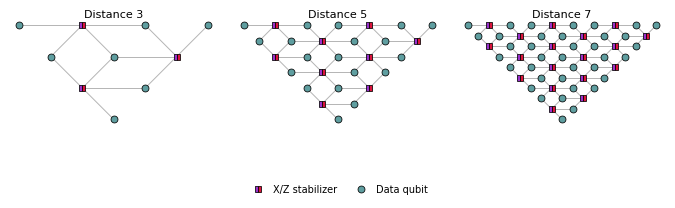

In [8]:
import importlib
import plot_colour_code_lattices

# Reload local edits when this cell is rerun in an existing Jupyter kernel.
importlib.reload(plot_colour_code_lattices)
plot_colour_codes_side_by_side = plot_colour_code_lattices.plot_colour_codes_side_by_side

# One 17 cm-wide figure: fits A4 paper with 2 cm left/right margins.
plot_colour_codes_side_by_side('triangular_colour_codes_d3_d5_d7.png')
plt.show()

## Generic hypergraph-product construction
This diagram explains how two potentially different classical parity-check matrices produce the two data-qubit sectors and the X- and Z-stabilizer sectors of a CSS hypergraph-product code.

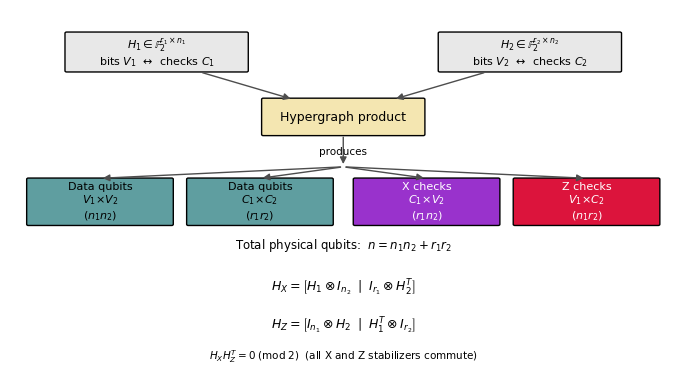

In [9]:
import importlib
import plot_hgp_construction

importlib.reload(plot_hgp_construction)
plot_hgp_construction.plot_hgp_construction(
    'hypergraph_product_construction.png'
)
plt.show()

## Smallest asymmetric repetition-product HGP code
The complete $HGP(\mathrm{rep}(5),\mathrm{rep}(3))=[[23,1,d_X=3,d_Z=5]]$ code is shown below. Its unequal horizontal and vertical repetition-code lengths give different X and Z distances. Squeezing changes the relative quadrature noise but not this stabilizer connectivity.

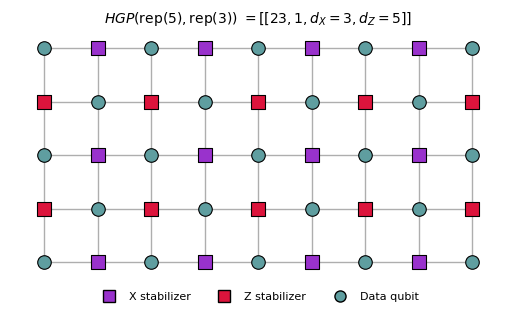

In [10]:
import importlib
import plot_asymmetric_hgp_code

importlib.reload(plot_asymmetric_hgp_code)
plot_asymmetric_hgp_code.plot_asymmetric_repetition_hgp(
    d_z=5, d_x=3, save_path='asymmetric_hgp_5x3_code.png'
)
plt.show()

## Toric-code lattice embedded on a torus
This complements the flat periodic fundamental-domain view above. The node colours and shapes are unchanged: purple squares are $X$ star stabilisers, red squares are $Z$ plaquette stabilisers, and blue circles are data qubits on edges.

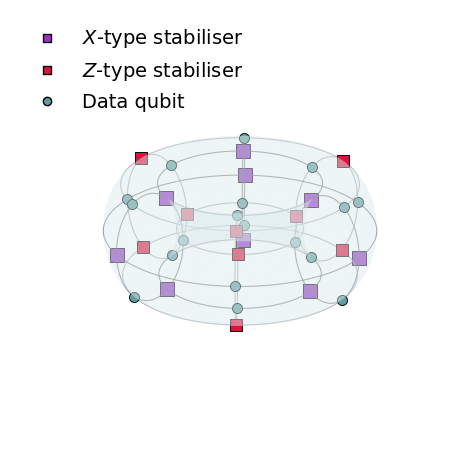

In [19]:
import importlib
import plot_toric_code_on_torus

importlib.reload(plot_toric_code_on_torus)
plot_toric_code_on_torus.plot_toric_code_on_torus(
    d=3,
    save_path='toric_code_on_torus.png',
    figsize=(8.0, 4.0),       # Shorter canvas reduces lower whitespace
    title='',                 # Empty string removes the title
    title_fontsize=12,
    legend_fontsize=14,
    legend_marker_size=10,    # Size of the legend squares and circle
    torus_vertical_position=-0.14,  # More negative moves only the torus down
    torus_zoom=1.25,           # Values above 1 enlarge the whole torus
    node_scale=1.5,           # Increase or decrease all node sizes
    x_label=r'$X$-type stabiliser',
    z_label=r'$Z$-type stabiliser',
    qubit_label='Data qubit',
)
plt.show()